In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/nikunjkumaragarwal/civicfix-dataset/CivicFix_Dataset.csv
/kaggle/input/datasets/nikunjkumaragarwal/civicfix-dataset/test/road_potholes_and_road_cracks/008083.jpg
/kaggle/input/datasets/nikunjkumaragarwal/civicfix-dataset/test/road_potholes_and_road_cracks/008147.jpg
/kaggle/input/datasets/nikunjkumaragarwal/civicfix-dataset/test/road_potholes_and_road_cracks/007419.jpg
/kaggle/input/datasets/nikunjkumaragarwal/civicfix-dataset/test/road_potholes_and_road_cracks/008633.jpg
/kaggle/input/datasets/nikunjkumaragarwal/civicfix-dataset/test/road_potholes_and_road_cracks/007273.jpg
/kaggle/input/datasets/nikunjkumaragarwal/civicfix-dataset/test/road_potholes_and_road_cracks/007267.jpg
/kaggle/input/datasets/nikunjkumaragarwal/civicfix-dataset/test/road_potholes_and_road_cracks/007464.jpg
/kaggle/input/datasets/nikunjkumaragarwal/civicfix-dataset/test/road_potholes_and_road_cracks/008049.jpg
/kaggle/input/datasets/nikunjkumaragarwal/civicfix-dataset/test/road_potholes_an

In [2]:
import os
import json
import copy
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from tqdm.auto import tqdm

# Hyperparameters and Reproducibility

In [4]:
# =========================
# CONFIGURATION
# =========================

DATA_DIR = "/kaggle/input/datasets/nikunjkumaragarwal/civicfix-dataset"

TRAIN_DIR = os.path.join(DATA_DIR, "train")
TEST_DIR = os.path.join(DATA_DIR, "test")

IMG_SIZE = 224
BATCH_SIZE = 32
NUM_EPOCHS = 4

NUM_WORKERS = 4

LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4

SEED = 42

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", DEVICE)

Device: cuda


In [5]:
def set_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # For reproducibility
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(SEED)

In [6]:
print("Train directory:", TRAIN_DIR)
print("Test directory :", TEST_DIR)

print("\nTrain classes:")
print(os.listdir(TRAIN_DIR))

print("\nTest classes:")
print(os.listdir(TEST_DIR))

Train directory: /kaggle/input/datasets/nikunjkumaragarwal/civicfix-dataset/train
Test directory : /kaggle/input/datasets/nikunjkumaragarwal/civicfix-dataset/test

Train classes:
['road_potholes_and_road_cracks', 'infrastructure_damaged_electric_wire_pole', 'infrastructure_damaged_concrete', 'traffic_broken_road_sign', 'waterlogging', 'cleanliness_fallen_tree', 'cleanliness_garbage']

Test classes:
['road_potholes_and_road_cracks', 'infrastructure_damaged_electric_wire_pole', 'infrastructure_damaged_concrete', 'traffic_broken_road_sign', 'waterlogging', 'cleanliness_fallen_tree', 'cleanliness_garbage']


# Duplicate Analysis

In [7]:
import os
import hashlib
from collections import defaultdict

IMAGE_EXTENSIONS = (
    ".jpg", ".jpeg", ".png",
    ".bmp", ".webp"
)

def get_image_files(root_dir):
    files = []

    for root, _, filenames in os.walk(root_dir):
        for filename in filenames:
            if filename.lower().endswith(IMAGE_EXTENSIONS):
                files.append(os.path.join(root, filename))

    return files


def file_hash(filepath):
    sha = hashlib.sha256()

    with open(filepath, "rb") as f:
        for chunk in iter(lambda: f.read(8192), b""):
            sha.update(chunk)

    return sha.hexdigest()


train_files = get_image_files(TRAIN_DIR)
test_files = get_image_files(TEST_DIR)

print("Train images:", len(train_files))
print("Test images :", len(test_files))

Train images: 10305
Test images : 2577


In [8]:
train_hashes = {}

for filepath in train_files:
    h = file_hash(filepath)
    train_hashes[h] = filepath


duplicate_pairs = []

for filepath in test_files:
    h = file_hash(filepath)

    if h in train_hashes:
        duplicate_pairs.append(
            (train_hashes[h], filepath)
        )


print("\nExact duplicate images:", len(duplicate_pairs))


Exact duplicate images: 164


In [9]:
print("Number of duplicate pairs:", len(duplicate_pairs))

for i, (train_file, test_file) in enumerate(duplicate_pairs[:30]):
    print(f"\nDuplicate {i+1}")
    print("TRAIN:", train_file)
    print("TEST :", test_file)

Number of duplicate pairs: 164

Duplicate 1
TRAIN: /kaggle/input/datasets/nikunjkumaragarwal/civicfix-dataset/train/traffic_broken_road_sign/006104.jpg
TEST : /kaggle/input/datasets/nikunjkumaragarwal/civicfix-dataset/test/traffic_broken_road_sign/006472.jpg

Duplicate 2
TRAIN: /kaggle/input/datasets/nikunjkumaragarwal/civicfix-dataset/train/traffic_broken_road_sign/005751.jpg
TEST : /kaggle/input/datasets/nikunjkumaragarwal/civicfix-dataset/test/traffic_broken_road_sign/006055.jpg

Duplicate 3
TRAIN: /kaggle/input/datasets/nikunjkumaragarwal/civicfix-dataset/train/traffic_broken_road_sign/005286.jpg
TEST : /kaggle/input/datasets/nikunjkumaragarwal/civicfix-dataset/test/traffic_broken_road_sign/006501.jpg

Duplicate 4
TRAIN: /kaggle/input/datasets/nikunjkumaragarwal/civicfix-dataset/train/traffic_broken_road_sign/006135.jpg
TEST : /kaggle/input/datasets/nikunjkumaragarwal/civicfix-dataset/test/traffic_broken_road_sign/005220.jpg

Duplicate 5
TRAIN: /kaggle/input/datasets/nikunjkumaraga

In [10]:
for i, (train_file, test_file) in enumerate(duplicate_pairs[:20]):

    train_class = os.path.basename(
        os.path.dirname(train_file)
    )

    test_class = os.path.basename(
        os.path.dirname(test_file)
    )

    print(
        f"{i+1:3d} | "
        f"Train: {train_class:<50} | "
        f"Test: {test_class}"
    )

  1 | Train: traffic_broken_road_sign                           | Test: traffic_broken_road_sign
  2 | Train: traffic_broken_road_sign                           | Test: traffic_broken_road_sign
  3 | Train: traffic_broken_road_sign                           | Test: traffic_broken_road_sign
  4 | Train: traffic_broken_road_sign                           | Test: traffic_broken_road_sign
  5 | Train: traffic_broken_road_sign                           | Test: traffic_broken_road_sign
  6 | Train: traffic_broken_road_sign                           | Test: traffic_broken_road_sign
  7 | Train: traffic_broken_road_sign                           | Test: traffic_broken_road_sign
  8 | Train: traffic_broken_road_sign                           | Test: traffic_broken_road_sign
  9 | Train: traffic_broken_road_sign                           | Test: traffic_broken_road_sign
 10 | Train: traffic_broken_road_sign                           | Test: traffic_broken_road_sign
 11 | Train: traffic_broken_ro

In [11]:
from collections import Counter
import os

duplicate_class_counts = Counter()

for train_file, test_file in duplicate_pairs:

    train_class = os.path.basename(
        os.path.dirname(train_file)
    )

    test_class = os.path.basename(
        os.path.dirname(test_file)
    )

    duplicate_class_counts[
        (train_class, test_class)
    ] += 1


print("Duplicate distribution:")
print("=" * 70)

for (train_class, test_class), count in duplicate_class_counts.items():

    print(
        f"{train_class:<55} "
        f"→ {test_class:<55} "
        f"{count}"
    )

Duplicate distribution:
traffic_broken_road_sign                                → traffic_broken_road_sign                                163
waterlogging                                            → waterlogging                                            1


In [12]:
duplicate_class_counts = Counter()

for train_file, test_file in duplicate_pairs:

    cls = os.path.basename(
        os.path.dirname(train_file)
    )

    duplicate_class_counts[cls] += 1


print("\nDuplicates per class")
print("=" * 60)

for cls, count in duplicate_class_counts.most_common():
    print(f"{cls:<55} {count:>5}")


Duplicates per class
traffic_broken_road_sign                                  163
waterlogging                                                1


In [13]:
import re

def extract_number(filepath):
    filename = os.path.basename(filepath)
    match = re.search(r"(\d+)", filename)

    if match:
        return int(match.group(1))

    return None


print("First 30 duplicate filename pairs:")
print("=" * 80)

for train_file, test_file in duplicate_pairs[:30]:

    train_num = extract_number(train_file)
    test_num = extract_number(test_file)

    print(
        f"Train: {train_num:>6}   "
        f"Test: {test_num:>6}"
    )

First 30 duplicate filename pairs:
Train:   6104   Test:   6472
Train:   5751   Test:   6055
Train:   5286   Test:   6501
Train:   6135   Test:   5220
Train:   5180   Test:   6204
Train:   5244   Test:   5021
Train:   6499   Test:   5124
Train:   6112   Test:   6017
Train:   5592   Test:   6745
Train:   6610   Test:   5605
Train:   5909   Test:   6782
Train:   6633   Test:   5005
Train:   5275   Test:   5604
Train:   4910   Test:   4980
Train:   6309   Test:   6213
Train:   5748   Test:   5266
Train:   5290   Test:   6508
Train:   5900   Test:   5464
Train:   5491   Test:   6639
Train:   5178   Test:   5906
Train:   5171   Test:   5477
Train:   6253   Test:   6324
Train:   6529   Test:   5177
Train:   6139   Test:   4967
Train:   5463   Test:   6841
Train:   5227   Test:   6648
Train:   5538   Test:   5627
Train:   6215   Test:   6835
Train:   6393   Test:   6163
Train:   5713   Test:   5300


# Near Duplicates

In [14]:
!pip install ImageHash -q

In [17]:
import os
import imagehash
from PIL import Image
from tqdm.auto import tqdm

IMAGE_EXTENSIONS = (
    ".jpg", ".jpeg", ".png",
    ".bmp", ".webp"
)

def get_image_files(root_dir):
    files = []

    for root, _, filenames in os.walk(root_dir):
        for filename in filenames:
            if filename.lower().endswith(IMAGE_EXTENSIONS):
                files.append(os.path.join(root, filename))

    return files


train_files = get_image_files(TRAIN_DIR)
test_files = get_image_files(TEST_DIR)

print("Train images:", len(train_files))
print("Test images :", len(test_files))

Train images: 10305
Test images : 2577


In [18]:
def calculate_phash(filepath):
    try:
        image = Image.open(filepath).convert("RGB")
        return imagehash.phash(image)
    except Exception:
        return None


train_phashes = {}

print("Hashing TRAIN images...")

for filepath in tqdm(train_files):
    h = calculate_phash(filepath)

    if h is not None:
        train_phashes[filepath] = h


test_phashes = {}

print("Hashing TEST images...")

for filepath in tqdm(test_files):
    h = calculate_phash(filepath)

    if h is not None:
        test_phashes[filepath] = h


print("\nTrain hashes:", len(train_phashes))
print("Test hashes :", len(test_phashes))

Hashing TRAIN images...


  0%|          | 0/10305 [00:00<?, ?it/s]

Hashing TEST images...


  0%|          | 0/2577 [00:00<?, ?it/s]


Train hashes: 10305
Test hashes : 2577


In [19]:
# 0       = identical perceptual hash
# 1–5     = extremely similar
# 6–10    = potentially similar
# >10     = increasingly different
near_duplicates = []

print("Searching for near-duplicates...")

for test_file, test_hash in tqdm(test_phashes.items()):

    best_distance = 65
    best_train_file = None

    for train_file, train_hash in train_phashes.items():

        distance = test_hash - train_hash

        if distance < best_distance:
            best_distance = distance
            best_train_file = train_file

    if best_distance <= 5:

        near_duplicates.append(
            (
                best_train_file,
                test_file,
                best_distance
            )
        )

print("\n======================================")
print("NEAR-DUPLICATE RESULTS")
print("======================================")
print("Near-duplicate pairs (distance <= 5):",
      len(near_duplicates))

Searching for near-duplicates...


  0%|          | 0/2577 [00:00<?, ?it/s]


NEAR-DUPLICATE RESULTS
Near-duplicate pairs (distance <= 5): 416


In [20]:
for i, (train_file, test_file, distance) in enumerate(
    near_duplicates[:50]
):

    train_class = os.path.basename(
        os.path.dirname(train_file)
    )

    test_class = os.path.basename(
        os.path.dirname(test_file)
    )

    print(f"\nPair {i+1}")
    print(f"Distance : {distance}")
    print(f"Class    : {train_class}")
    print(f"TRAIN    : {train_file}")
    print(f"TEST     : {test_file}")


Pair 1
Distance : 4
Class    : road_potholes_and_road_cracks
TRAIN    : /kaggle/input/datasets/nikunjkumaragarwal/civicfix-dataset/train/road_potholes_and_road_cracks/008196.jpg
TEST     : /kaggle/input/datasets/nikunjkumaragarwal/civicfix-dataset/test/road_potholes_and_road_cracks/007273.jpg

Pair 2
Distance : 0
Class    : road_potholes_and_road_cracks
TRAIN    : /kaggle/input/datasets/nikunjkumaragarwal/civicfix-dataset/train/road_potholes_and_road_cracks/008179.jpg
TEST     : /kaggle/input/datasets/nikunjkumaragarwal/civicfix-dataset/test/road_potholes_and_road_cracks/008379.jpg

Pair 3
Distance : 4
Class    : road_potholes_and_road_cracks
TRAIN    : /kaggle/input/datasets/nikunjkumaragarwal/civicfix-dataset/train/road_potholes_and_road_cracks/008004.jpg
TEST     : /kaggle/input/datasets/nikunjkumaragarwal/civicfix-dataset/test/road_potholes_and_road_cracks/007184.jpg

Pair 4
Distance : 4
Class    : road_potholes_and_road_cracks
TRAIN    : /kaggle/input/datasets/nikunjkumaragarwal/

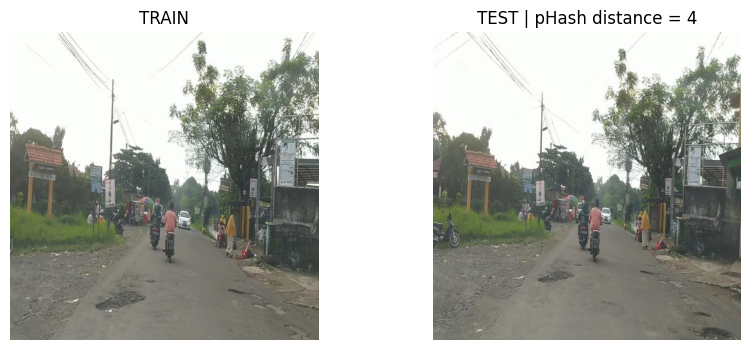

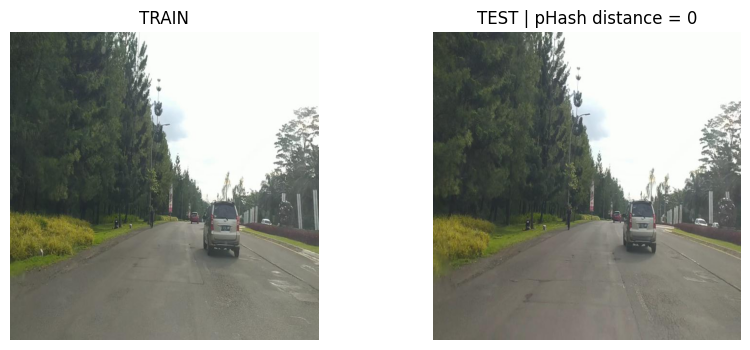

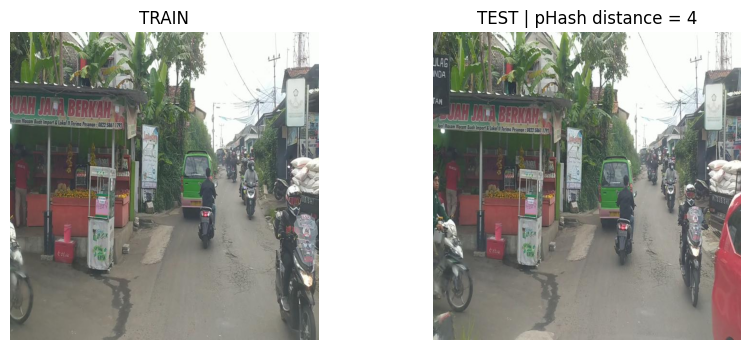

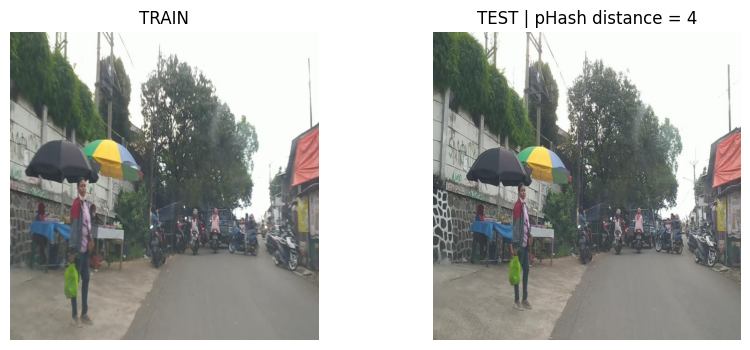

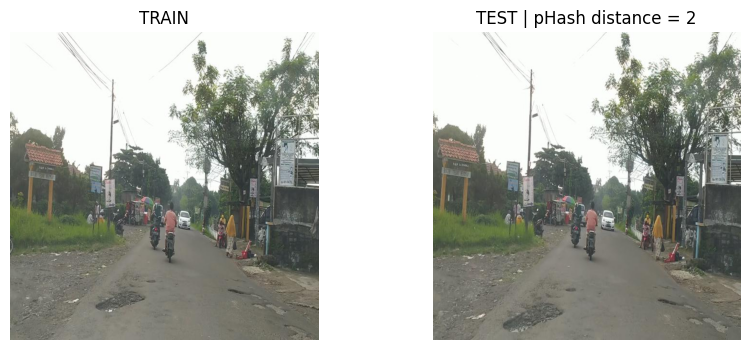

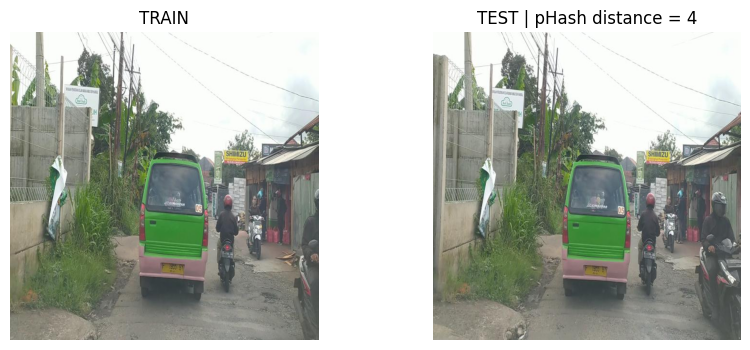

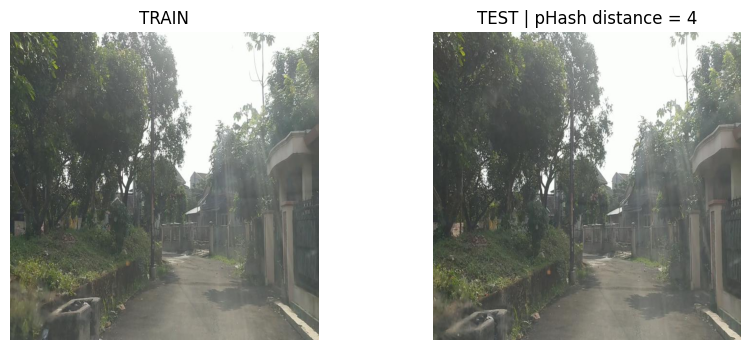

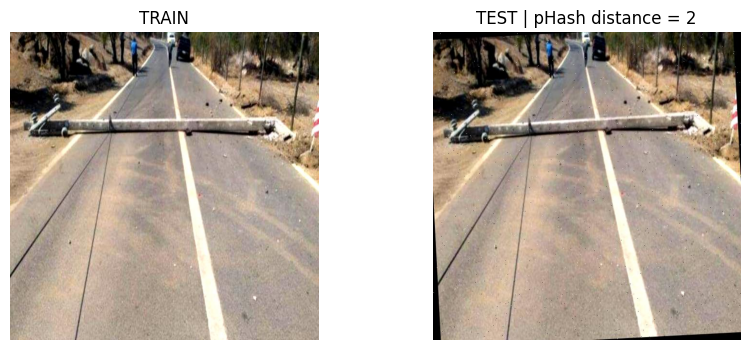

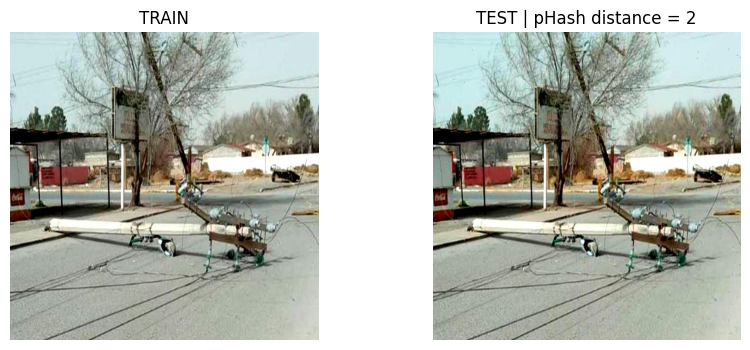

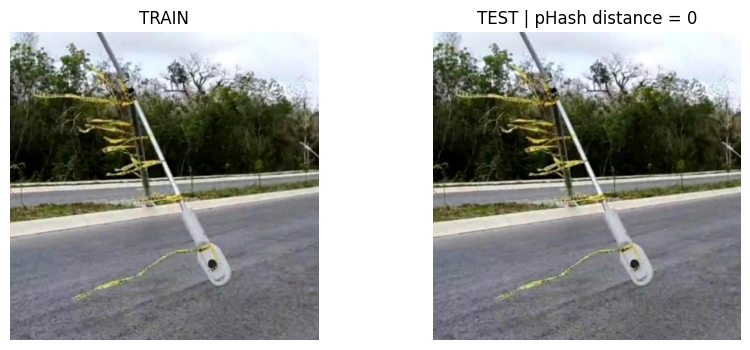

In [21]:
import matplotlib.pyplot as plt

for train_file, test_file, distance in near_duplicates[:10]:

    train_img = Image.open(train_file).convert("RGB")
    test_img = Image.open(test_file).convert("RGB")

    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    plt.imshow(train_img)
    plt.title("TRAIN")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(test_img)
    plt.title(f"TEST | pHash distance = {distance}")
    plt.axis("off")

    plt.show()

In [23]:
from collections import Counter

distance_counts = Counter(
    distance
    for _, _, distance in near_duplicates
)

print("pHash distance distribution")
print("=" * 40)

for distance in sorted(distance_counts):
    print(f"Distance {distance}: {distance_counts[distance]}")

pHash distance distribution
Distance 0: 300
Distance 2: 64
Distance 4: 52


# Creating New test images

In [24]:
import os
import shutil

# ==========================================
# SETTINGS
# ==========================================

CLEAN_TEST_DIR = "/kaggle/working/civicfix_clean_test_v2"

# Recommended starting threshold
NEAR_DUPLICATE_THRESHOLD = 3


# ==========================================
# REMOVE OLD DIRECTORY IF IT EXISTS
# ==========================================

if os.path.exists(CLEAN_TEST_DIR):
    shutil.rmtree(CLEAN_TEST_DIR)


# ==========================================
# CREATE CLASS DIRECTORIES
# ==========================================

for class_name in os.listdir(TEST_DIR):

    class_path = os.path.join(TEST_DIR, class_name)

    if os.path.isdir(class_path):

        os.makedirs(
            os.path.join(CLEAN_TEST_DIR, class_name),
            exist_ok=True
        )


# ==========================================
# EXACT DUPLICATE TEST FILES
# ==========================================

exact_duplicate_test_files = set(
    test_file
    for _, test_file in duplicate_pairs
)


# ==========================================
# NEAR-DUPLICATE TEST FILES
# ==========================================

near_duplicate_test_files = set()

for train_file, test_file, distance in near_duplicates:

    # Skip exact duplicates here
    # They are already included above
    if test_file in exact_duplicate_test_files:
        continue

    # Remove only sufficiently close matches
    if distance <= NEAR_DUPLICATE_THRESHOLD:
        near_duplicate_test_files.add(test_file)


# ==========================================
# COMBINE ALL LEAKED TEST FILES
# ==========================================

files_to_remove = (
    exact_duplicate_test_files
    | near_duplicate_test_files
)


print("=" * 60)
print("DATA CLEANING SUMMARY")
print("=" * 60)
print(
    "Exact duplicate test images:",
    len(exact_duplicate_test_files)
)
print(
    f"Additional near duplicates "
    f"(distance <= {NEAR_DUPLICATE_THRESHOLD}):",
    len(near_duplicate_test_files)
)
print(
    "Total test images to remove:",
    len(files_to_remove)
)


# ==========================================
# COPY CLEAN TEST DATASET
# ==========================================

removed_exact = 0
removed_near = 0
copied = 0


for root, dirs, files in os.walk(TEST_DIR):

    for filename in files:

        if not filename.lower().endswith(
            (".jpg", ".jpeg", ".png", ".bmp", ".webp")
        ):
            continue


        source_path = os.path.join(root, filename)


        # ----------------------------------
        # REMOVE EXACT DUPLICATE
        # ----------------------------------

        if source_path in exact_duplicate_test_files:

            removed_exact += 1
            continue


        # ----------------------------------
        # REMOVE NEAR DUPLICATE
        # ----------------------------------

        if source_path in near_duplicate_test_files:

            removed_near += 1
            continue


        # ----------------------------------
        # COPY CLEAN IMAGE
        # ----------------------------------

        class_name = os.path.basename(root)

        destination_dir = os.path.join(
            CLEAN_TEST_DIR,
            class_name
        )

        destination_path = os.path.join(
            destination_dir,
            filename
        )

        shutil.copy2(
            source_path,
            destination_path
        )

        copied += 1


# ==========================================
# FINAL RESULTS
# ==========================================

print("\n" + "=" * 60)
print("FINAL CLEAN TEST DATASET")
print("=" * 60)

print("Original test images :", len(test_files))
print("Exact removed        :", removed_exact)
print("Near removed         :", removed_near)
print("Total removed        :", removed_exact + removed_near)
print("Clean test images    :", copied)

DATA CLEANING SUMMARY
Exact duplicate test images: 164
Additional near duplicates (distance <= 3): 200
Total test images to remove: 364

FINAL CLEAN TEST DATASET
Original test images : 2577
Exact removed        : 164
Near removed         : 200
Total removed        : 364
Clean test images    : 2213


# Normalization of Images

In [26]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.05
    ),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

# Dataset Stats

In [30]:
train_dataset = datasets.ImageFolder(
    root=TRAIN_DIR,
    transform=train_transform
)

test_dataset = datasets.ImageFolder(
    root=CLEAN_TEST_DIR,
    transform=test_transform
)


print("Number of training images:", len(train_dataset))
print("Number of test images:", len(test_dataset))

print("\nClass mapping:")
print(train_dataset.class_to_idx)

Number of training images: 10305
Number of test images: 2213

Class mapping:
{'cleanliness_fallen_tree': 0, 'cleanliness_garbage': 1, 'infrastructure_damaged_concrete': 2, 'infrastructure_damaged_electric_wire_pole': 3, 'road_potholes_and_road_cracks': 4, 'traffic_broken_road_sign': 5, 'waterlogging': 6}


In [31]:
assert train_dataset.class_to_idx == test_dataset.class_to_idx

class_names = train_dataset.classes

print("Classes:")
for idx, name in enumerate(class_names):
    print(idx, "→", name)

Classes:
0 → cleanliness_fallen_tree
1 → cleanliness_garbage
2 → infrastructure_damaged_concrete
3 → infrastructure_damaged_electric_wire_pole
4 → road_potholes_and_road_cracks
5 → traffic_broken_road_sign
6 → waterlogging


In [32]:
from collections import Counter

train_counts = Counter(train_dataset.targets)
test_counts = Counter(test_dataset.targets)

print("TRAIN")
for idx, name in enumerate(class_names):
    print(f"{name:50s}: {train_counts[idx]}")

print("\nTEST")
for idx, name in enumerate(class_names):
    print(f"{name:50s}: {test_counts[idx]}")

TRAIN
cleanliness_fallen_tree                           : 1600
cleanliness_garbage                               : 1600
infrastructure_damaged_concrete                   : 1600
infrastructure_damaged_electric_wire_pole         : 1600
road_potholes_and_road_cracks                     : 1600
traffic_broken_road_sign                          : 1600
waterlogging                                      : 705

TEST
cleanliness_fallen_tree                           : 378
cleanliness_garbage                               : 342
infrastructure_damaged_concrete                   : 400
infrastructure_damaged_electric_wire_pole         : 344
road_potholes_and_road_cracks                     : 398
traffic_broken_road_sign                          : 176
waterlogging                                      : 175


In [33]:
clean_test_dataset = datasets.ImageFolder(
    root=CLEAN_TEST_DIR,
    transform=test_transform
)

clean_test_loader = DataLoader(
    clean_test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print("Clean test images:", len(clean_test_dataset))
print("Classes:", clean_test_dataset.classes)

Clean test images: 2213
Classes: ['cleanliness_fallen_tree', 'cleanliness_garbage', 'infrastructure_damaged_concrete', 'infrastructure_damaged_electric_wire_pole', 'road_potholes_and_road_cracks', 'traffic_broken_road_sign', 'waterlogging']


In [34]:
assert clean_test_dataset.class_to_idx == train_dataset.class_to_idx

print("✓ Class mappings match")

✓ Class mappings match


# Data Loaders

In [35]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

test_loader = DataLoader(
    clean_test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print("Train batches:", len(train_loader))
print("Test batches:", len(test_loader))

Train batches: 323
Test batches: 70


In [36]:
def denormalize(image):
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)

    image = image.cpu() * std + mean
    return torch.clamp(image, 0, 1)

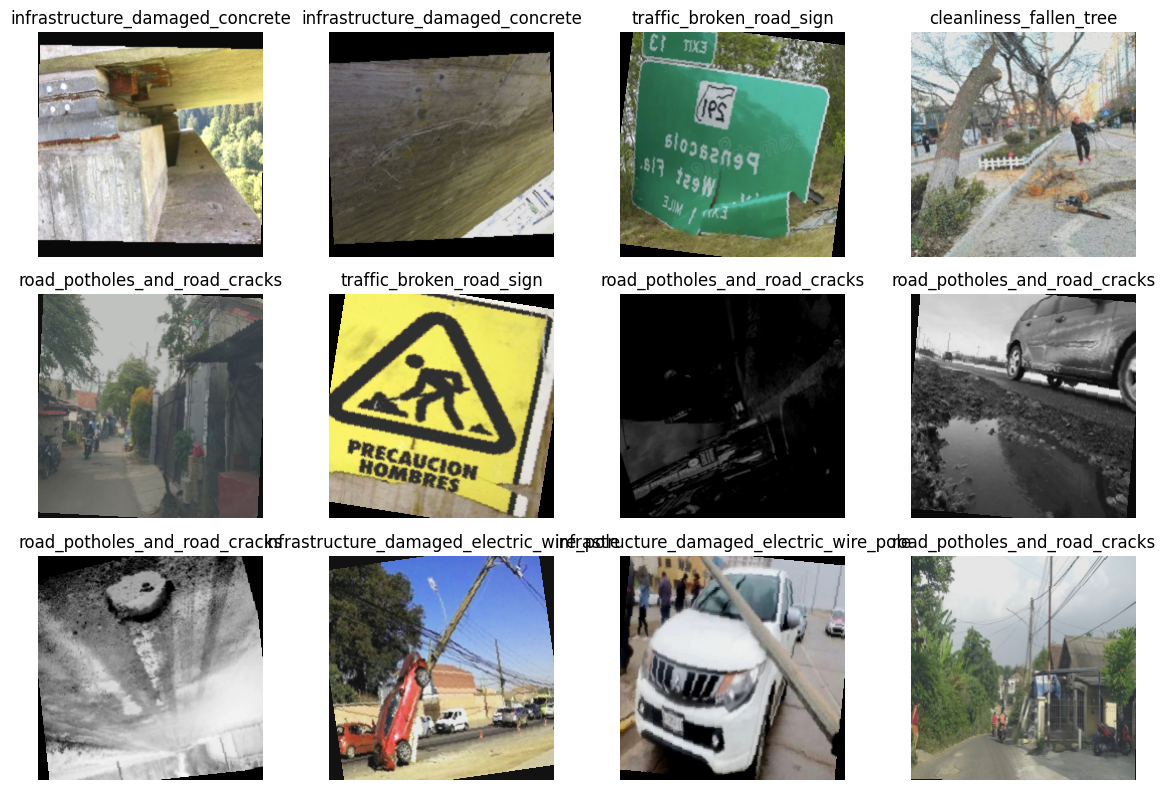

In [37]:
images, labels = next(iter(train_loader))

plt.figure(figsize=(12, 8))

for i in range(min(12, len(images))):
    plt.subplot(3, 4, i + 1)

    image = denormalize(images[i])
    image = image.permute(1, 2, 0)

    plt.imshow(image)
    plt.title(class_names[labels[i].item()])
    plt.axis("off")

plt.tight_layout()
plt.show()

# Model Loading and Training/Finetuning

## Model Loading

In [38]:
weights = models.ResNet50_Weights.IMAGENET1K_V2

model = models.resnet50(weights=weights)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 197MB/s] 


In [39]:
num_features = model.fc.in_features

model.fc = nn.Sequential(
    nn.Dropout(p=0.3),
    nn.Linear(num_features, len(class_names))
)

model = model.to(DEVICE)

print(model.fc)

Sequential(
  (0): Dropout(p=0.3, inplace=False)
  (1): Linear(in_features=2048, out_features=7, bias=True)
)


## Defining Optimizer

In [40]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

## Defining Scheduler

In [41]:
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=NUM_EPOCHS
)

## Train and Validation Functions

In [42]:
def train_one_epoch(model, loader, criterion, optimizer, device):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    progress_bar = tqdm(
        loader,
        desc="Training",
        leave=False
    )

    for images, labels in progress_bar:

        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        progress_bar.set_postfix(
            loss=loss.item()
        )

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy

In [43]:
def evaluate(model, loader, criterion, device):

    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    all_labels = []
    all_predictions = []

    with torch.no_grad():

        progress_bar = tqdm(
            loader,
            desc="Testing",
            leave=False
        )

        for images, labels in progress_bar:

            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            all_labels.extend(labels.cpu().numpy())
            all_predictions.extend(predicted.cpu().numpy())

    loss = running_loss / total
    accuracy = correct / total

    return loss, accuracy, np.array(all_labels), np.array(all_predictions)

## Training and Best Model

In [44]:
history = {
    "train_loss": [],
    "train_accuracy": [],
    "test_loss": [],
    "test_accuracy": []
}

best_test_accuracy = 0.0
best_model_weights = copy.deepcopy(model.state_dict())

start_time = time.time()

for epoch in range(NUM_EPOCHS):

    print(f"\nEpoch [{epoch + 1}/{NUM_EPOCHS}]")

    train_loss, train_accuracy = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        DEVICE
    )

    test_loss, test_accuracy, _, _ = evaluate(
        model,
        test_loader,
        criterion,
        DEVICE
    )

    scheduler.step()

    history["train_loss"].append(train_loss)
    history["train_accuracy"].append(train_accuracy)

    history["test_loss"].append(test_loss)
    history["test_accuracy"].append(test_accuracy)

    print(
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy * 100:.2f}%"
    )

    print(
        f"Test Loss:  {test_loss:.4f} | "
        f"Test Acc:  {test_accuracy * 100:.2f}%"
    )

    if test_accuracy > best_test_accuracy:

        best_test_accuracy = test_accuracy

        best_model_weights = copy.deepcopy(
            model.state_dict()
        )

        torch.save(
            {
                "model_state_dict": model.state_dict(),
                "class_names": class_names,
                "class_to_idx": train_dataset.class_to_idx,
                "epoch": epoch + 1,
                "test_accuracy": test_accuracy
            },
            "/kaggle/working/best_resnet50_civicfix.pth"
        )

        print("✓ Best model saved!")

elapsed_time = time.time() - start_time

print(
    f"\nTraining completed in "
    f"{elapsed_time / 60:.2f} minutes"
)


Epoch [1/4]


Training:   0%|          | 0/323 [00:00<?, ?it/s]

Testing:   0%|          | 0/70 [00:00<?, ?it/s]

Train Loss: 0.3751 | Train Acc: 89.70%
Test Loss:  0.1019 | Test Acc:  96.79%
✓ Best model saved!

Epoch [2/4]


Training:   0%|          | 0/323 [00:00<?, ?it/s]

...

Train Loss: 0.0512 | Train Acc: 98.47%
Test Loss:  0.0515 | Test Acc:  98.24%
✓ Best model saved!

Epoch [4/4]


Training:   0%|          | 0/323 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7aef2eaa7240>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7aef2eaa7240>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

Testing:   0%|          | 0/70 [00:00<?, ?it/s]

Train Loss: 0.0300 | Train Acc: 99.21%
Test Loss:  0.0374 | Test Acc:  99.01%
✓ Best model saved!

Training completed in 9.44 minutes


# Best Model Loading

In [45]:
checkpoint = torch.load(
    "/kaggle/working/best_resnet50_civicfix.pth",
    map_location=DEVICE
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model.eval()

print("Best epoch:", checkpoint["epoch"])
print(
    "Best test accuracy:",
    checkpoint["test_accuracy"] * 100
)

Best epoch: 4
Best test accuracy: 99.00587437867149


# Evaluation Metrics and Visualizations

In [46]:
test_loss, test_accuracy, y_true, y_pred = evaluate(
    model,
    test_loader,
    criterion,
    DEVICE
)

print(f"\nFinal Test Accuracy: {test_accuracy * 100:.2f}%")

Testing:   0%|          | 0/70 [00:00<?, ?it/s]


Final Test Accuracy: 99.01%


In [47]:
precision = precision_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

recall = recall_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

f1 = f1_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

print(f"Macro Precision: {precision:.4f}")
print(f"Macro Recall:    {recall:.4f}")
print(f"Macro F1:        {f1:.4f}")

Macro Precision: 0.9911
Macro Recall:    0.9912
Macro F1:        0.9911


In [48]:
report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4,
    zero_division=0
)

print(report)

                                           precision    recall  f1-score   support

                  cleanliness_fallen_tree     0.9791    0.9894    0.9842       378
                      cleanliness_garbage     0.9882    0.9795    0.9838       342
          infrastructure_damaged_concrete     0.9900    0.9950    0.9925       400
infrastructure_damaged_electric_wire_pole     0.9883    0.9797    0.9839       344
            road_potholes_and_road_cracks     0.9975    0.9950    0.9962       398
                 traffic_broken_road_sign     1.0000    1.0000    1.0000       176
                             waterlogging     0.9943    1.0000    0.9972       175

                                 accuracy                         0.9901      2213
                                macro avg     0.9911    0.9912    0.9911      2213
                             weighted avg     0.9901    0.9901    0.9901      2213



<Figure size 1000x800 with 0 Axes>

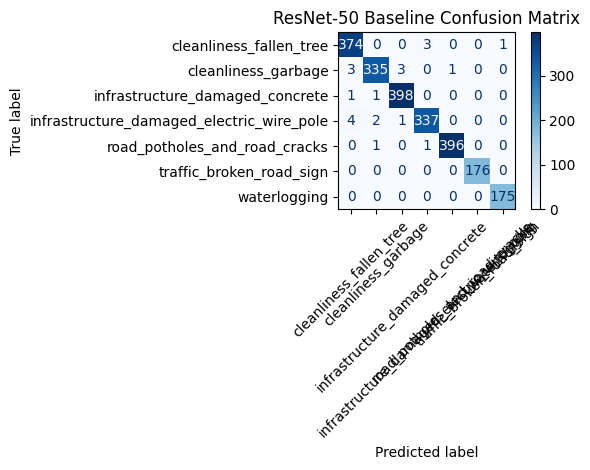

In [49]:
cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(10, 8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(
    cmap="Blues",
    xticks_rotation=45
)

plt.title("ResNet-50 Baseline Confusion Matrix")
plt.tight_layout()

plt.savefig(
    "/kaggle/working/resnet50_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

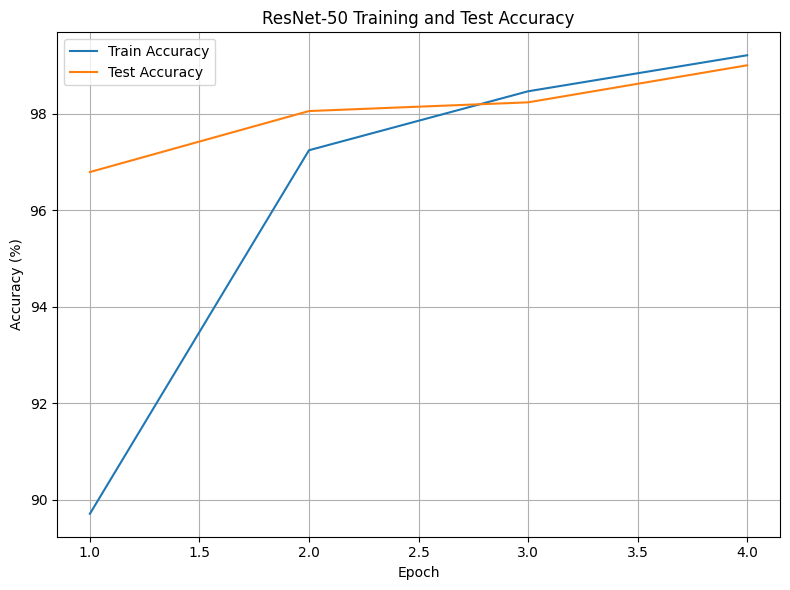

In [50]:
epochs = range(1, NUM_EPOCHS + 1)

plt.figure(figsize=(8, 6))

plt.plot(
    epochs,
    np.array(history["train_accuracy"]) * 100,
    label="Train Accuracy"
)

plt.plot(
    epochs,
    np.array(history["test_accuracy"]) * 100,
    label="Test Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("ResNet-50 Training and Test Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    "/kaggle/working/resnet50_accuracy_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

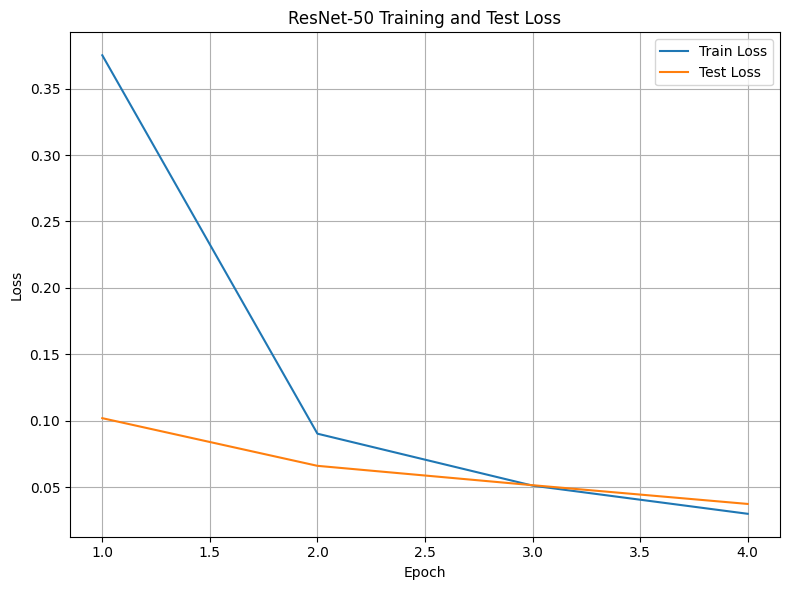

In [51]:
plt.figure(figsize=(8, 6))

plt.plot(
    epochs,
    history["train_loss"],
    label="Train Loss"
)

plt.plot(
    epochs,
    history["test_loss"],
    label="Test Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ResNet-50 Training and Test Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    "/kaggle/working/resnet50_loss_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [52]:
from sklearn.metrics import precision_recall_fscore_support

precision_per_class, recall_per_class, f1_per_class, support = \
    precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=range(len(class_names)),
        zero_division=0
    )

results_df = pd.DataFrame({
    "Class": class_names,
    "Precision": precision_per_class,
    "Recall": recall_per_class,
    "F1": f1_per_class,
    "Support": support
})

results_df

,Class,Precision,Recall,F1,Support
0,cleanliness_fallen_tree,0.979058,0.989418,0.984211,378
1,cleanliness_garbage,0.988201,0.979532,0.983847,342
2,infrastructure_damaged_concrete,0.990050,0.995000,0.992519,400
3,infrastructure_damaged_electric_wire_pole,0.988270,0.979651,0.983942,344
4,road_potholes_and_road_cracks,0.997481,0.994975,0.996226,398
5,traffic_broken_road_sign,1.000000,1.000000,1.000000,176
6,waterlogging,0.994318,1.000000,0.997151,175


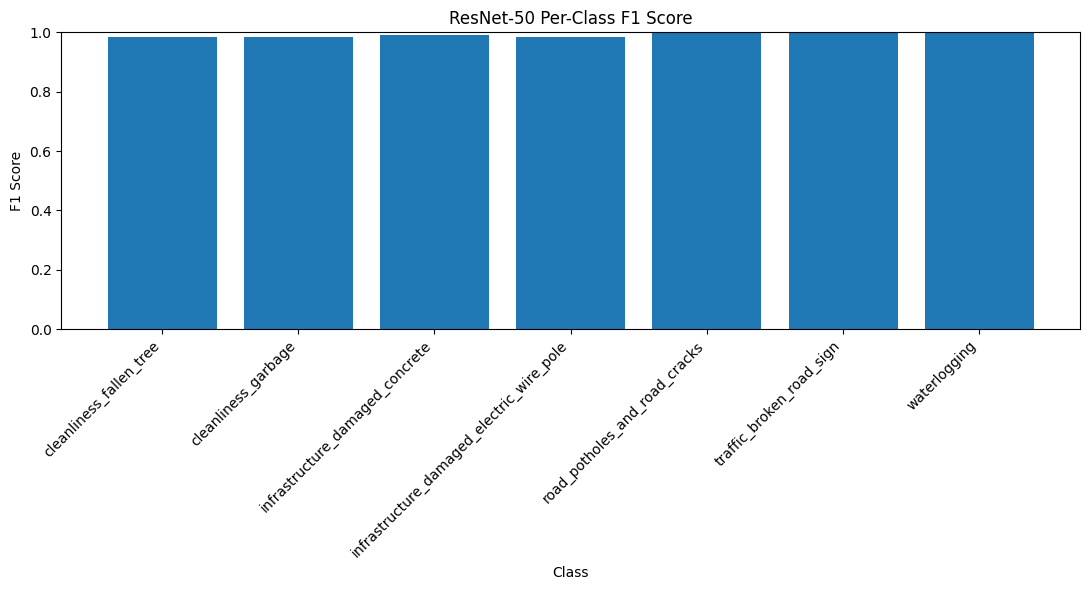

In [53]:
plt.figure(figsize=(11, 6))

plt.bar(
    class_names,
    f1_per_class
)

plt.ylabel("F1 Score")
plt.xlabel("Class")
plt.title("ResNet-50 Per-Class F1 Score")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1)

plt.tight_layout()

plt.savefig(
    "/kaggle/working/resnet50_per_class_f1.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Saving the Results

In [54]:
results = {
    "model": "ResNet-50",
    "num_classes": len(class_names),
    "image_size": IMG_SIZE,
    "batch_size": BATCH_SIZE,
    "epochs": NUM_EPOCHS,
    "test_accuracy": float(test_accuracy),
    "macro_precision": float(precision),
    "macro_recall": float(recall),
    "macro_f1": float(f1)
}

with open(
    "/kaggle/working/resnet50_results.json",
    "w"
) as f:
    json.dump(results, f, indent=4)

print(json.dumps(results, indent=4))

{
    "model": "ResNet-50",
    "num_classes": 7,
    "image_size": 224,
    "batch_size": 32,
    "epochs": 4,
    "test_accuracy": 0.9900587437867149,
    "macro_precision": 0.9910538596698931,
    "macro_recall": 0.9912251700461766,
    "macro_f1": 0.9911279330070275
}


In [55]:
clean_test_loss, clean_test_accuracy, clean_y_true, clean_y_pred = evaluate(
    model,
    clean_test_loader,
    criterion,
    DEVICE
)

print(
    f"\nClean Test Accuracy: "
    f"{clean_test_accuracy * 100:.2f}%"
)

Testing:   0%|          | 0/70 [00:00<?, ?it/s]


Clean Test Accuracy: 99.01%


In [56]:
with open(
    "/kaggle/working/class_names.json",
    "w"
) as f:

    json.dump(
        {
            "classes": class_names,
            "class_to_idx": train_dataset.class_to_idx
        },
        f,
        indent=4
    )